In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
monthly_df = pd.read_csv(
    "data/processed/monthly_passenger_demand.csv"
)

monthly_df["Month"] = pd.to_datetime(monthly_df["Month"])

monthly_df = (
    monthly_df
    .sort_values("Month")
    .reset_index(drop=True)
)

In [3]:
monthly_df["Lag_1"] = (
    monthly_df["Passenger Count"].shift(1)
)

monthly_df["Lag_2"] = (
    monthly_df["Passenger Count"].shift(2)
)

monthly_df["Lag_12"] = (
    monthly_df["Passenger Count"].shift(12)
)

monthly_df["Rolling_Mean_3"] = (
    monthly_df["Passenger Count"]
    .shift(1)
    .rolling(3)
    .mean()
)

monthly_df["Rolling_Mean_12"] = (
    monthly_df["Passenger Count"]
    .shift(1)
    .rolling(12)
    .mean()
)

monthly_df["Month_Number"] = (
    monthly_df["Month"].dt.month
)

In [4]:
monthly_df = (
    monthly_df
    .dropna()
    .reset_index(drop=True)
)

In [5]:
features = [
    "Lag_1",
    "Lag_2",
    "Lag_12",
    "Rolling_Mean_3",
    "Rolling_Mean_12",
    "Month_Number"
]

X = monthly_df[features]
y = monthly_df["Passenger Count"]

In [6]:
X.head()

,Lag_1,Lag_2,Lag_12,Rolling_Mean_3,Rolling_Mean_12,Month_Number
0,3900043.0,3508679.0,3976746.0,3.600446e+06,3.382044e+06,7
1,3996985.0,3900043.0,3972694.0,3.801902e+06,3.383730e+06,8
2,3980297.0,3996985.0,3341964.0,3.959108e+06,3.384364e+06,9
3,3327730.0,3980297.0,3468846.0,3.768337e+06,3.383178e+06,10
4,3335161.0,3327730.0,3145240.0,3.547729e+06,3.372037e+06,11


In [7]:
split_index = int(len(monthly_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [8]:
print("Training period:")
print(monthly_df["Month"].iloc[:split_index].min())
print(monthly_df["Month"].iloc[:split_index].max())

print("\nTesting period:")
print(monthly_df["Month"].iloc[split_index:].min())
print(monthly_df["Month"].iloc[split_index:].max())

Training period:
2000-07-01 00:00:00
2021-03-01 00:00:00

Testing period:
2021-04-01 00:00:00
2026-06-01 00:00:00


In [9]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

In [10]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [11]:
y_pred = model.predict(X_test)

In [12]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("Random Forest MAE:", mae)
print("Random Forest RMSE:", rmse)

Random Forest MAE: 334348.8397619048
Random Forest RMSE: 447614.8323598247


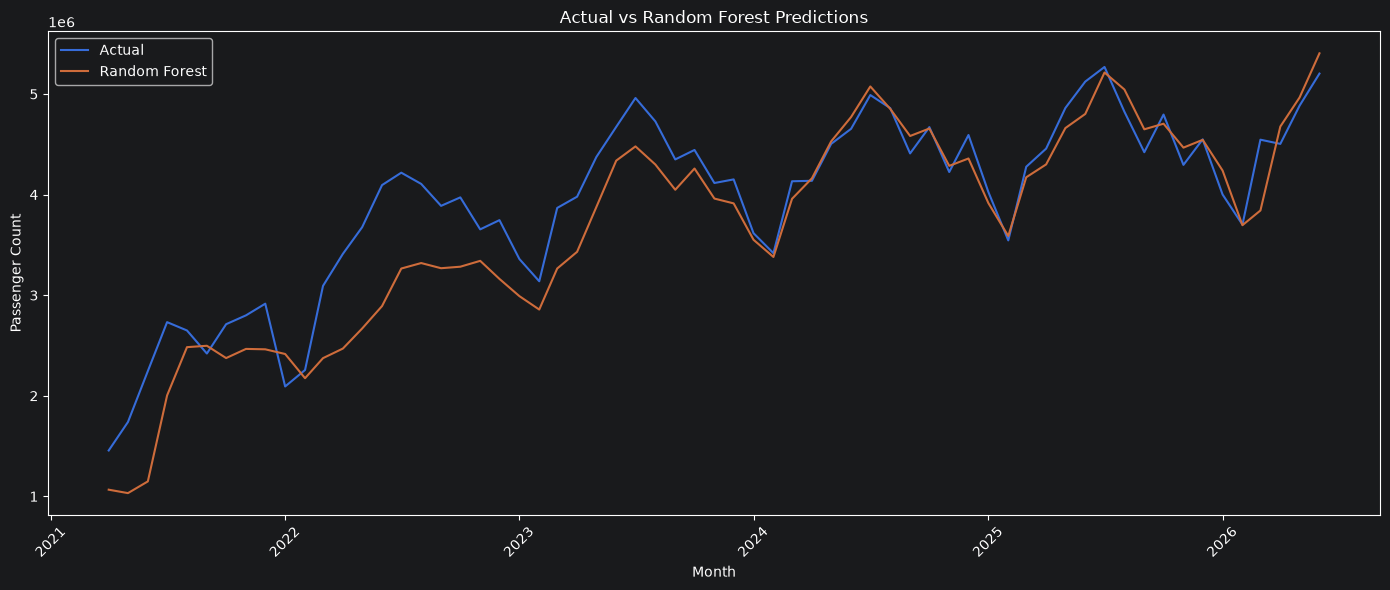

In [13]:
comparison = pd.DataFrame({
    "Month": monthly_df["Month"].iloc[split_index:],
    "Actual": y_test.values,
    "Predicted": y_pred
})

plt.figure(figsize=(14, 6))

plt.plot(
    comparison["Month"],
    comparison["Actual"],
    label="Actual"
)

plt.plot(
    comparison["Month"],
    comparison["Predicted"],
    label="Random Forest"
)

plt.xlabel("Month")
plt.ylabel("Passenger Count")
plt.title("Actual vs Random Forest Predictions")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

           Feature  Importance
0            Lag_1    0.686285
2           Lag_12    0.177947
3   Rolling_Mean_3    0.086726
1            Lag_2    0.028944
4  Rolling_Mean_12    0.015925
5     Month_Number    0.004174


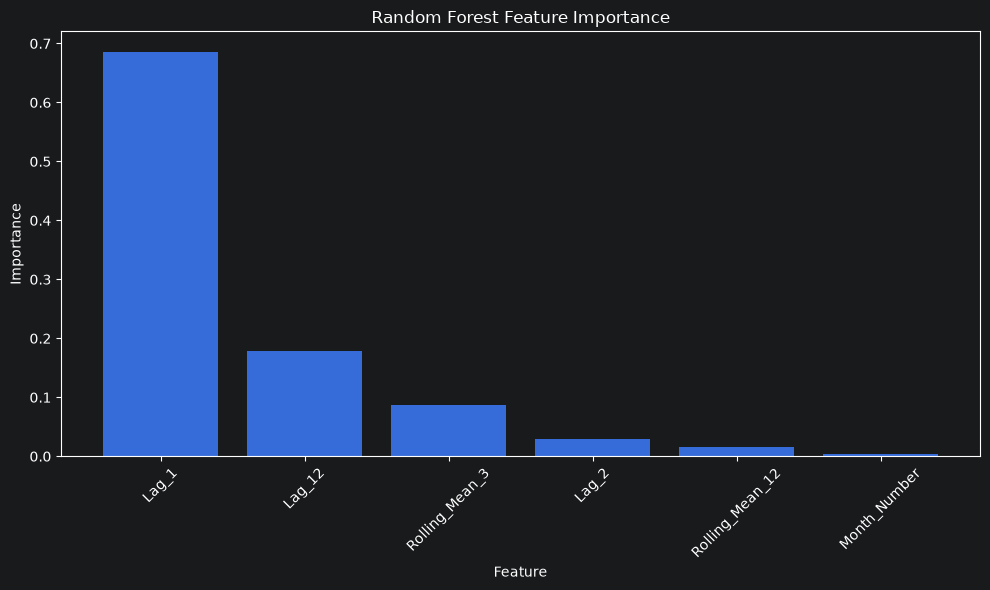

In [15]:
plt.figure(figsize=(10, 6))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
results = pd.DataFrame({
    "Model": [
        "Previous Month Baseline",
        "Linear Regression",
        "Feature-Engineered Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        326970.923077,
        322999.101710,
        320793.764324,
        mae
    ],
    "RMSE": [
        384439.041719,
        377807.990227,
        388692.518306,
        rmse
    ]
})

print(results.round(2))

                                  Model        MAE       RMSE
0               Previous Month Baseline  326970.92  384439.04
1                     Linear Regression  322999.10  377807.99
2  Feature-Engineered Linear Regression  320793.76  388692.52
3                         Random Forest  334348.84  447614.83


In [17]:
print("Training target range:")
print(y_train.min(), "to", y_train.max())

print("\nTest target range:")
print(y_test.min(), "to", y_test.max())

print("\nRandom Forest prediction range:")
print(y_pred.min(), "to", y_pred.max())

Training target range:
138817 to 5742437

Test target range:
1455944 to 5269263

Random Forest prediction range:
1032088.915 to 5404770.115


Day 6 Observations

1. Random Forest was less successful than the other models tested, including the previous months baseline model. It produced an MAE of 334,348.84 and an RMSE of 447,614.83, compared with 326,970.92 and 384,439.04 for the baseline.

2. The prediction chart indicates that the Random Forest under-predicts in certain parts of the test period, most notably in the passenger-demand recovery period. This indicates that the model had difficulty tracking some of the increases in demand.

3. The training target range was 138,817 to 5,742,437, while the test target range was 1,455,944 to 5,269,263. The Random Forest was thus not required to forecast the number of passengers that are not in the range of targets for which the model was trained. This weaker performance is not therefore simply due to the model not being able to extrapolate beyond the range of the training target.

4. From feature-importance output, it is found that the feature ‘Lag_1’ had the highest feature importance with about 69% followed by ‘Lag_12’ with about 18%. The other features were not nearly as significant.

5. The high importance for Lag_1 indicates that the passenger demand of this period was the most significant historical signal that the Random Forest used. This is in line with the relatively strong contribution of the previous month's baseline in this forecasting problem.

6. The difference between the RMSE and MAE was the highest for the Random Forest. This means that some of the prediction errors were much larger than the median error, and had a more significant impact on the RMSE.

Total, no improvement was seen on this set using the Random Forest. This illustrates that it is not always a more complex model that yields better predictions, especially if the historical features available for the model do not contain sufficient information to model changes in demand.